<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Conteo_de_Objetos_con_CNN_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO('yolov8n.pt')  # modelo ligero

from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

results = model(image_path)

# Mostrar resultados
result = results[0]

# Conteo de objetos
object_counts = {}

for box in result.boxes:
    cls = int(box.cls[0])
    label = model.names[cls]

    if label in object_counts:
        object_counts[label] += 1
    else:
        object_counts[label] = 1

print("Conteo de objetos:")
for obj, count in object_counts.items():
    print(f"{obj}: {count}")

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO('yolov8n.pt')  # modelo ligero

In [ ]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

Saving ejemploBicicletas.jpg to ejemploBicicletas.jpg


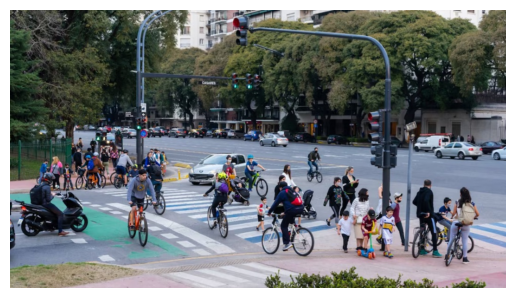

In [ ]:
img = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
results = model(image_path)

# Mostrar resultados
result = results[0]

# Conteo de objetos
object_counts = {}

for box in result.boxes:
    cls = int(box.cls[0])
    label = model.names[cls]

    if label in object_counts:
        object_counts[label] += 1
    else:
        object_counts[label] = 1

print("Conteo de objetos:")
for obj, count in object_counts.items():
    print(f"{obj}: {count}")


image 1/1 /content/ejemploBicicletas.jpg: 384x640 23 persons, 8 bicycles, 13 cars, 1 motorcycle, 1 traffic light, 146.0ms
Speed: 3.5ms preprocess, 146.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Conteo de objetos:
bicycle: 8
car: 13
motorcycle: 1
person: 23
traffic light: 1


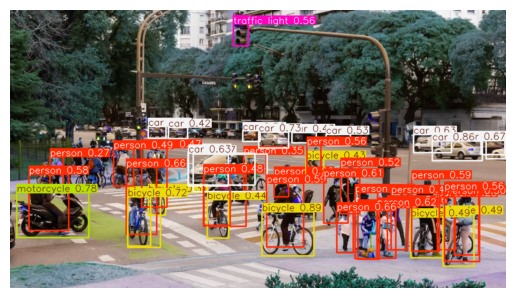

In [ ]:
annotated_img = result.plot()

plt.imshow(annotated_img)
plt.axis('off')
plt.show()

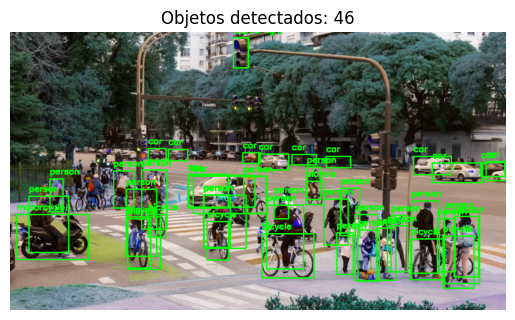

In [ ]:
import time
from IPython.display import clear_output

img_copy = img.copy()

for i, box in enumerate(result.boxes):
    temp_img = img_copy.copy()

    # Dibujar TODAS las cajas hasta el momento (acumulativo)
    for j in range(i + 1):
        b = result.boxes[j]
        x1, y1, x2, y2 = map(int, b.xyxy[0])
        cls = int(b.cls[0])
        label = model.names[cls]

        cv2.rectangle(temp_img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(temp_img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    clear_output(wait=True)
    plt.imshow(temp_img)
    plt.axis('off')
    plt.title(f"Objetos detectados: {i+1}")
    plt.show()

    time.sleep(0.2)  # velocidad de animación

In [ ]:
frames = []
img_copy = img.copy()

for i, box in enumerate(result.boxes):
    temp_img = img_copy.copy()

    for j in range(i + 1):
        b = result.boxes[j]
        x1, y1, x2, y2 = map(int, b.xyxy[0])
        cls = int(b.cls[0])
        label = model.names[cls]

        cv2.rectangle(temp_img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(temp_img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    frames.append(cv2.cvtColor(temp_img, cv2.COLOR_RGB2BGR))

# Guardar video
height, width, _ = frames[0].shape
out = cv2.VideoWriter('deteccion_animada.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      2, (width, height))

for frame in frames:
    out.write(frame)

out.release()

In [ ]:
frames = []
img_copy = img.copy()

for i, box in enumerate(result.boxes):
    temp_img = img_copy.copy()

    for j in range(i + 1):
        b = result.boxes[j]
        x1, y1, x2, y2 = map(int, b.xyxy[0])
        cls = int(b.cls[0])
        label = model.names[cls]

        cv2.rectangle(temp_img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(temp_img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    frames.append(cv2.cvtColor(temp_img, cv2.COLOR_RGB2BGR))

# 👉 Duración deseada en segundos
duration = 5.5

# 👉 FPS dinámico
fps = len(frames) / duration

# Guardar video
height, width, _ = frames[0].shape
out = cv2.VideoWriter('deteccion_animada.mp4',
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps, (width, height))

for frame in frames:
    out.write(frame)

out.release()

print(f"Frames: {len(frames)} | FPS: {fps:.2f} | Duración: {duration}s")

Frames: 46 | FPS: 8.36 | Duración: 5.5s


In [ ]:
from google.colab import files

frames = []
img_copy = img.copy()  # Asegúrate que esté en BGR

for i, box in enumerate(result.boxes):
    temp_img = img_copy.copy()

    for j in range(i + 1):
        b = result.boxes[j]
        x1, y1, x2, y2 = map(int, b.xyxy[0])
        cls = int(b.cls[0])
        label = model.names[cls]

        cv2.rectangle(temp_img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(temp_img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    frames.append(temp_img)  # 👈 SIN conversión (BGR correcto)

# 🎯 Duración deseada
duration = 5.5
fps = len(frames) / duration

# Guardar video
height, width, _ = frames[0].shape
video_name = 'deteccion_animada.mp4'

out = cv2.VideoWriter(video_name,
                      cv2.VideoWriter_fourcc(*'mp4v'),
                      fps, (width, height))

for frame in frames:
    out.write(frame)

out.release()

print(f"Video generado: {video_name}")

# 📥 Descargar automáticamente
files.download(video_name)

Video generado: deteccion_animada.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

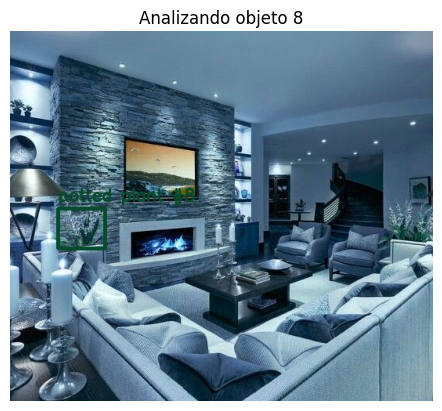

In [ ]:
import random
from IPython.display import clear_output

object_colors = {}

img_base = img.copy()

for i, box in enumerate(result.boxes):
    temp_img = img_base.copy()

    b = result.boxes[i]
    x1, y1, x2, y2 = map(int, b.xyxy[0])
    cls = int(b.cls[0])
    label = model.names[cls]

    # Asignar color único si no existe
    if i not in object_colors:
        object_colors[i] = [random.randint(0,255) for _ in range(3)]

    color = object_colors[i]

    # Dibujar SOLO el actual
    cv2.rectangle(temp_img, (x1, y1), (x2, y2), color, 3)
    cv2.putText(temp_img, f"{label} #{i+1}", (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    clear_output(wait=True)
    plt.imshow(temp_img)
    plt.axis('off')
    plt.title(f"Analizando objeto {i+1}")
    plt.show()

    time.sleep(0.6)